# Projeto Fase 6 — O Começo da Rede Neural

**Integrantes:**

- **Leandro Tenório** — RM 572083
- **João Pedro Iurovschi de Almeida Bessa** — RM 570160
- **Nícolas Xavier Costa** — RM 570336

**Curso:** Tecnologia em Inteligência Artificial  
**Instituição:** FIAP

## Objetivo

Este projeto explora diferentes abordagens de visão computacional para reconhecimento de objetos, comparando:

1. YOLO customizado para as classes `alicate` e `garrafa`;
2. YOLO pré-treinado sem customização;
3. CNN treinada do zero para classificação binária.

O conjunto de dados contém 80 imagens, sendo 40 de cada classe.

## Configuração do ambiente

O notebook utiliza arquivos armazenados no Google Drive. A biblioteca Ultralytics é instalada para os experimentos com YOLO.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!pip install ultralytics -q

In [12]:
import os
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Projeto_fase6")
print("Projeto encontrado:", BASE.exists())

Projeto encontrado: True


## 1. Preparação do Dataset

Foram utilizadas 80 imagens divididas igualmente entre as classes `alicate` e `garrafa`.

Para cada classe, as imagens foram distribuídas da seguinte forma:

- 32 imagens para treinamento
- 4 imagens para validação
- 4 imagens para teste

Total:

| Conjunto | Alicate | Garrafa | Total |
|---|---:|---:|---:|
| Treinamento | 32 | 32 | 64 |
| Validação | 4 | 4 | 8 |
| Teste | 4 | 4 | 8 |

As imagens foram rotuladas utilizando o Make Sense AI e exportadas no formato YOLO.

In [13]:
from pathlib import Path

base = Path("/content/drive/MyDrive/Projeto_fase6")

for split in ["train", "val", "test"]:
    imagens = list((base / "images" / split).glob("*"))
    labels = list((base / "labels" / split).glob("*.txt"))

    nomes_imagens = {img.stem for img in imagens}
    nomes_labels = {lbl.stem for lbl in labels}

    print(f"\n--- {split.upper()} ---")
    print("Imagens:", len(imagens))
    print("Labels:", len(labels))
    print("Imagens sem label:", nomes_imagens - nomes_labels)
    print("Labels sem imagem:", nomes_labels - nomes_imagens)


--- TRAIN ---
Imagens: 64
Labels: 64
Imagens sem label: set()
Labels sem imagem: set()

--- VAL ---
Imagens: 8
Labels: 8
Imagens sem label: set()
Labels sem imagem: set()

--- TEST ---
Imagens: 8
Labels: 8
Imagens sem label: set()
Labels sem imagem: set()


# 2. YOLO Customizado

Nesta etapa foi utilizado um modelo YOLO pré-treinado como ponto de partida, realizando treinamento específico sobre as classes `alicate` e `garrafa`.

Foram realizados dois experimentos, alterando a quantidade de épocas:

- Experimento 1: 30 épocas
- Experimento 2: 60 épocas

O objetivo foi avaliar o impacto do aumento do número de épocas sobre o desempenho do modelo.

### 2.1 Treinamento com 30 épocas

O primeiro experimento utilizou 30 épocas, mantendo `imgsz=640` e `batch=8`.

In [14]:
from ultralytics import YOLO

model_30 = YOLO("yolov5nu.pt")

resultado_30 = model_30.train(
    data="/content/drive/MyDrive/Projeto_fase6/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    project="/content/drive/MyDrive/Projeto_fase6/resultados",
    name="yolo_30_epocas"
)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Projeto_fase6/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5nu.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_30_epocas-4, nbs=64, nms=None, opset=None, optim

#### Validação — 30 épocas

O melhor peso (`best.pt`) do treinamento foi validado no conjunto de validação.

In [15]:
from ultralytics import YOLO

modelo_30 = YOLO(
    "/content/drive/MyDrive/Projeto_fase6/resultados/yolo_30_epocas-2/weights/best.pt"
)

print("✅ Modelo de 30 épocas carregado com sucesso.")

✅ Modelo de 30 épocas carregado com sucesso.


In [16]:
metricas_30 = modelo_30.val(
    data="/content/drive/MyDrive/Projeto_fase6/data.yaml",
    project="/content/drive/MyDrive/Projeto_fase6/resultados",
    name="validacao_30_epocas"
)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
YOLOv5n summary (fused): 84 layers, 2,503,334 parameters, 0 gradients, 7.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 52.2±13.7 MB/s, size: 65.0 KB)
val: Scanning /content/drive/MyDrive/Projeto_fase6/labels/val.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 1.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4s/it 1.4s
                   all          8          8          1      0.963      0.995      0.822
               alicate          4          4          1       0.96      0.995       0.82
               garrafa          4          4          1      0.965      0.995      0.824
Speed: 1.0ms preprocess, 144.4ms inference, 0.0ms loss, 13.8ms postprocess per image
Results saved to /content/drive/MyDrive/Projeto_fase6/resultados/validacao_30_epocas-2


### Resultados — 30 épocas

O modelo apresentou:

- Precision: 1,000
- Recall: 0,963
- mAP@0.5: 0,995
- mAP@0.5:0.95: 0,822

Os resultados indicaram elevada capacidade de detecção das duas classes. Entretanto, devido ao pequeno conjunto de validação, composto por apenas oito imagens, os resultados devem ser interpretados com cautela.

### 2.2 Treinamento com 60 épocas

O segundo experimento foi configurado para 60 épocas. A execução foi interrompida durante o processo e posteriormente retomada a partir do checkpoint `last.pt`, preservando o estado do treinamento.

O comando originalmente utilizado para iniciar o experimento foi:

In [17]:
from ultralytics import YOLO

model_60 = YOLO("yolov5nu.pt")

# Comando original de treinamento:
# resultado_60 = model_60.train(
#     data="/content/drive/MyDrive/Projeto_fase6/data.yaml",
#     epochs=60,
#     imgsz=640,
#     batch=8,
#     project="/content/drive/MyDrive/Projeto_fase6/resultados",
#     name="yolo_60_epocas"
# )

Após a interrupção, o treinamento foi retomado a partir do checkpoint salvo:

In [18]:
from ultralytics import YOLO

model_60 = YOLO(
    "/content/drive/MyDrive/Projeto_fase6/resultados/yolo_60_epocas/weights/last.pt"
)

model_60.train(resume=True)

WARNING ⚠️ model '/content/drive/MyDrive/Projeto_fase6/resultados/yolo_60_epocas/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, k

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0, 16, 17, 20, 25, 58])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b7ddd04aac0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

#### Validação — 60 épocas

Após a conclusão, o melhor peso do experimento foi validado no mesmo conjunto de validação.

In [19]:
from ultralytics import YOLO

modelo_60 = YOLO(
    "/content/drive/MyDrive/Projeto_fase6/resultados/yolo_60_epocas/weights/best.pt"
)

metricas_60 = modelo_60.val(
    data="/content/drive/MyDrive/Projeto_fase6/data.yaml",
    project="/content/drive/MyDrive/Projeto_fase6/resultados",
    name="validacao_60_epocas"
)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
YOLOv5n summary (fused): 84 layers, 2,503,334 parameters, 0 gradients, 7.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 80.2±16.9 MB/s, size: 80.2 KB)
val: Scanning /content/drive/MyDrive/Projeto_fase6/labels/val.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 1.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2s/it 1.2s
                   all          8          8      0.978      0.967      0.995       0.92
               alicate          4          4      0.955          1      0.995       0.92
               garrafa          4          4          1      0.933      0.995       0.92
Speed: 1.3ms preprocess, 123.4ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to /content/drive/MyDrive/Projeto_fase6/resultados/validacao_60_epocas-3


### Resultados — 60 épocas

O modelo apresentou:

- Precision: 0,978
- Recall: 0,967
- mAP@0.5: 0,995
- mAP@0.5:0.95: 0,920

O aumento de 30 para 60 épocas produziu uma melhora relevante no mAP@0.5:0.95, indicando melhor qualidade das bounding boxes quando avaliadas com critérios mais rigorosos de sobreposição.

### Comparação entre 30 e 60 épocas

| Métrica | 30 épocas | 60 épocas |
|---|---:|---:|
| Precision | 1,000 | 0,978 |
| Recall | 0,963 | 0,967 |
| mAP@0.5 | 0,995 | 0,995 |
| mAP@0.5:0.95 | 0,822 | 0,920 |

Embora a Precision tenha apresentado uma pequena redução, o modelo de 60 épocas obteve melhor Recall e uma melhora expressiva no mAP@0.5:0.95.

Com base nos resultados, o modelo treinado por 60 épocas foi selecionado como o melhor modelo YOLO customizado deste experimento.

### 2.3 Testes com imagens não utilizadas no treinamento

Os dois modelos foram aplicados ao mesmo conjunto de 8 imagens de teste.

In [20]:
from ultralytics import YOLO

modelo_30 = YOLO(
    "/content/drive/MyDrive/Projeto_fase6/resultados/yolo_30_epocas-2/weights/best.pt"
)

resultados_teste_30 = modelo_30.predict(
    source="/content/drive/MyDrive/Projeto_fase6/images/test",
    save=True,
    conf=0.25,
    project="/content/drive/MyDrive/Projeto_fase6/resultados",
    name="teste_30_epocas"
)


image 1/8 /content/drive/MyDrive/Projeto_fase6/images/test/alicate_002.jpeg: 480x640 1 alicate, 113.4ms
image 2/8 /content/drive/MyDrive/Projeto_fase6/images/test/alicate_015.jpeg: 480x640 1 alicate, 89.8ms
image 3/8 /content/drive/MyDrive/Projeto_fase6/images/test/alicate_028.jpeg: 640x480 1 alicate, 100.5ms
image 4/8 /content/drive/MyDrive/Projeto_fase6/images/test/alicate_029.jpeg: 640x480 1 alicate, 124.5ms
image 5/8 /content/drive/MyDrive/Projeto_fase6/images/test/garrafa_002.jpeg: 640x480 1 garrafa, 88.6ms
image 6/8 /content/drive/MyDrive/Projeto_fase6/images/test/garrafa_008.jpeg: 640x480 1 garrafa, 91.2ms
image 7/8 /content/drive/MyDrive/Projeto_fase6/images/test/garrafa_025.jpeg: 640x480 1 garrafa, 90.9ms
image 8/8 /content/drive/MyDrive/Projeto_fase6/images/test/garrafa_033.jpeg: 640x480 1 garrafa, 89.6ms
Speed: 3.4ms preprocess, 98.6ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/drive/MyDrive/Projeto_fase6/resultados/teste_30_e

In [21]:
resultados_teste_60 = modelo_60.predict(
    source="/content/drive/MyDrive/Projeto_fase6/images/test",
    save=True,
    conf=0.25,
    project="/content/drive/MyDrive/Projeto_fase6/resultados",
    name="teste_60_epocas"
)


image 1/8 /content/drive/MyDrive/Projeto_fase6/images/test/alicate_002.jpeg: 480x640 1 alicate, 92.9ms
image 2/8 /content/drive/MyDrive/Projeto_fase6/images/test/alicate_015.jpeg: 480x640 2 alicates, 85.3ms
image 3/8 /content/drive/MyDrive/Projeto_fase6/images/test/alicate_028.jpeg: 640x480 1 alicate, 98.9ms
image 4/8 /content/drive/MyDrive/Projeto_fase6/images/test/alicate_029.jpeg: 640x480 1 alicate, 90.0ms
image 5/8 /content/drive/MyDrive/Projeto_fase6/images/test/garrafa_002.jpeg: 640x480 1 garrafa, 85.6ms
image 6/8 /content/drive/MyDrive/Projeto_fase6/images/test/garrafa_008.jpeg: 640x480 1 garrafa, 87.3ms
image 7/8 /content/drive/MyDrive/Projeto_fase6/images/test/garrafa_025.jpeg: 640x480 1 garrafa, 90.0ms
image 8/8 /content/drive/MyDrive/Projeto_fase6/images/test/garrafa_033.jpeg: 640x480 2 garrafas, 91.8ms
Speed: 3.3ms preprocess, 90.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/drive/MyDrive/Projeto_fase6/resultados/teste_60_ep

## 3. Resultados Visuais do YOLO Customizado

As imagens abaixo apresentam exemplos de detecção realizadas pelo modelo sobre imagens que não participaram do treinamento.

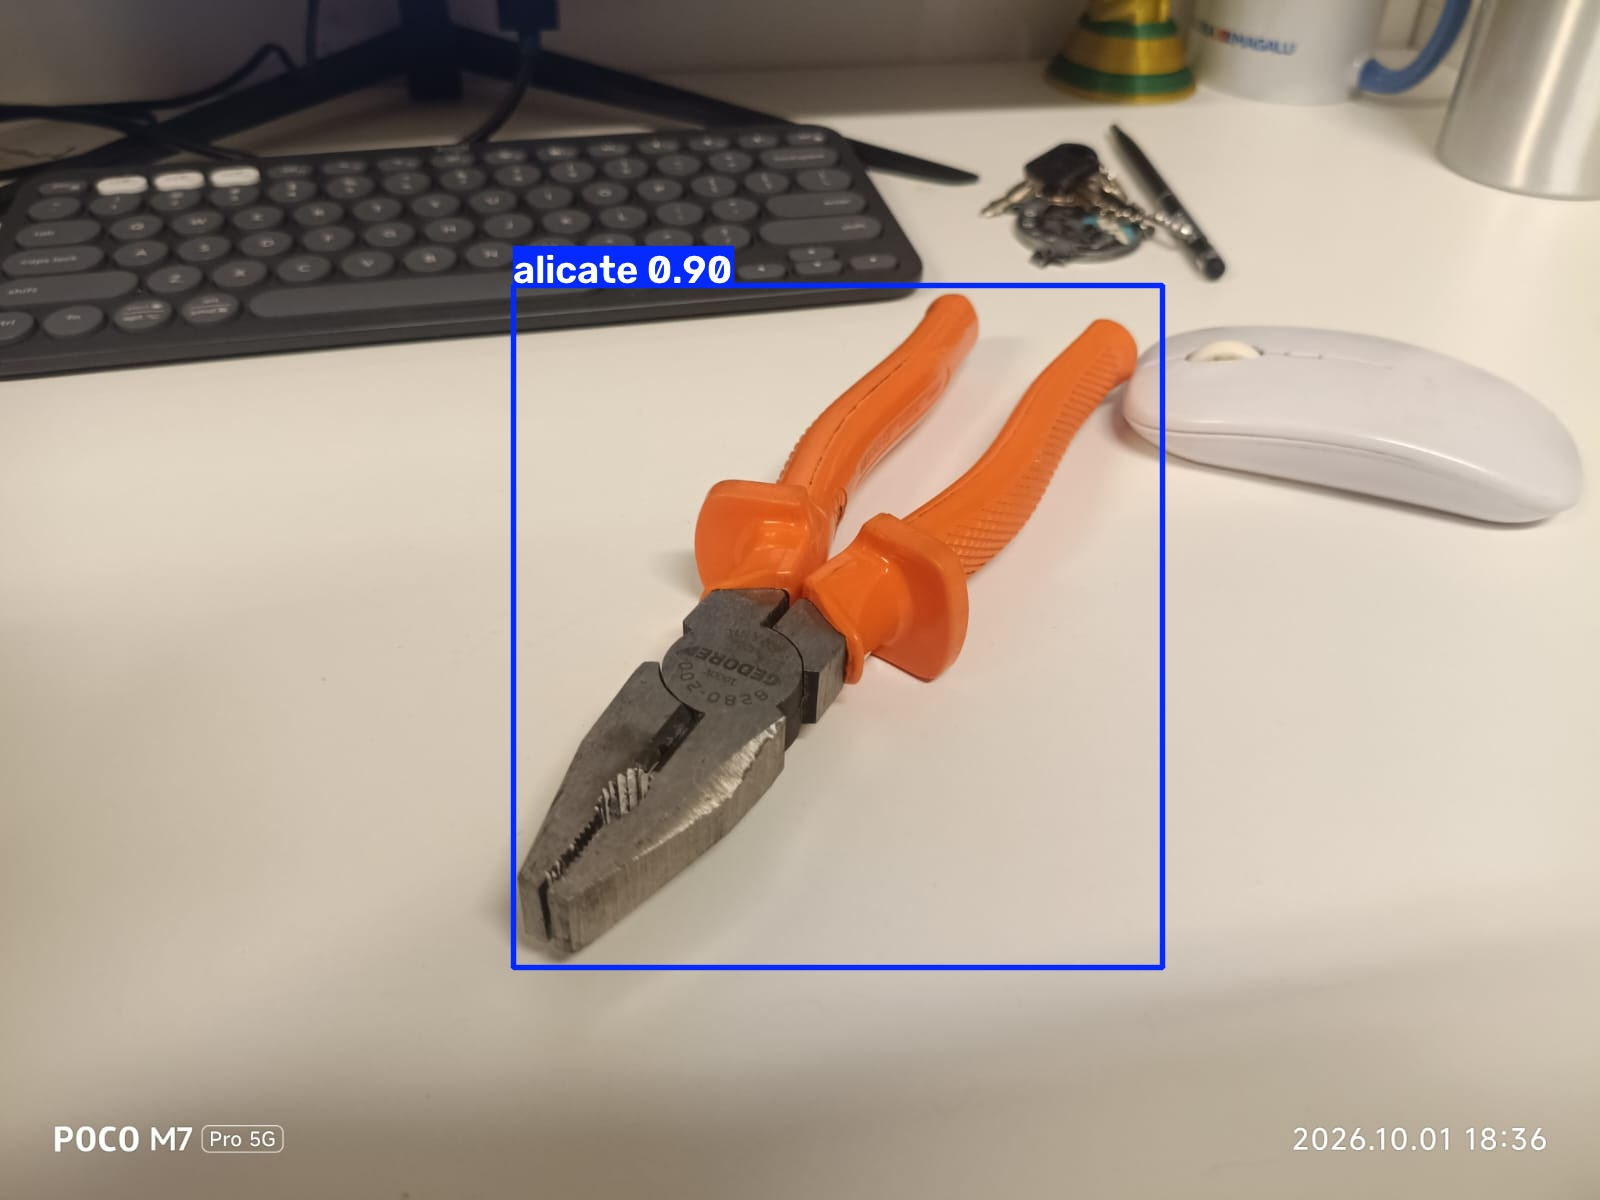

In [22]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/drive/MyDrive/Projeto_fase6/resultados/teste_30_epocas/alicate_002.jpg",
        width=500
    )
)

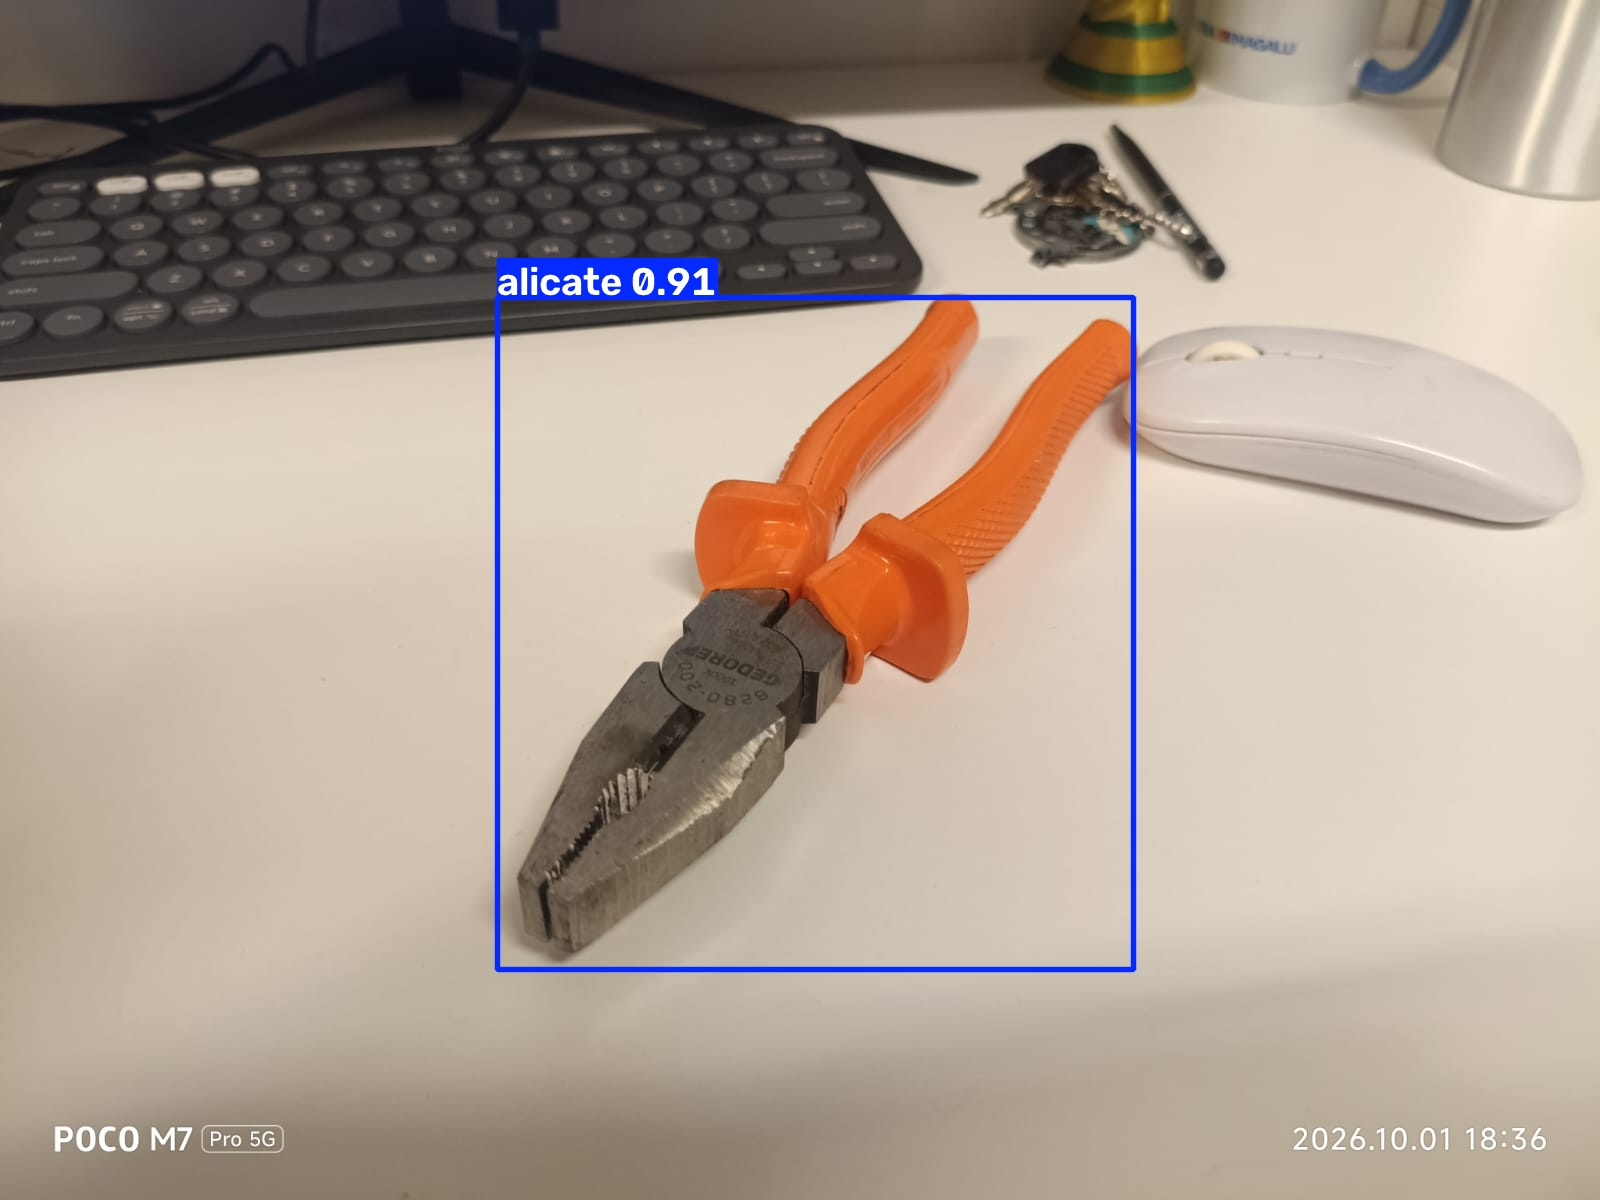

In [23]:
display(
    Image(
        filename="/content/drive/MyDrive/Projeto_fase6/resultados/teste_60_epocas/alicate_002.jpg",
        width=500
    )
)

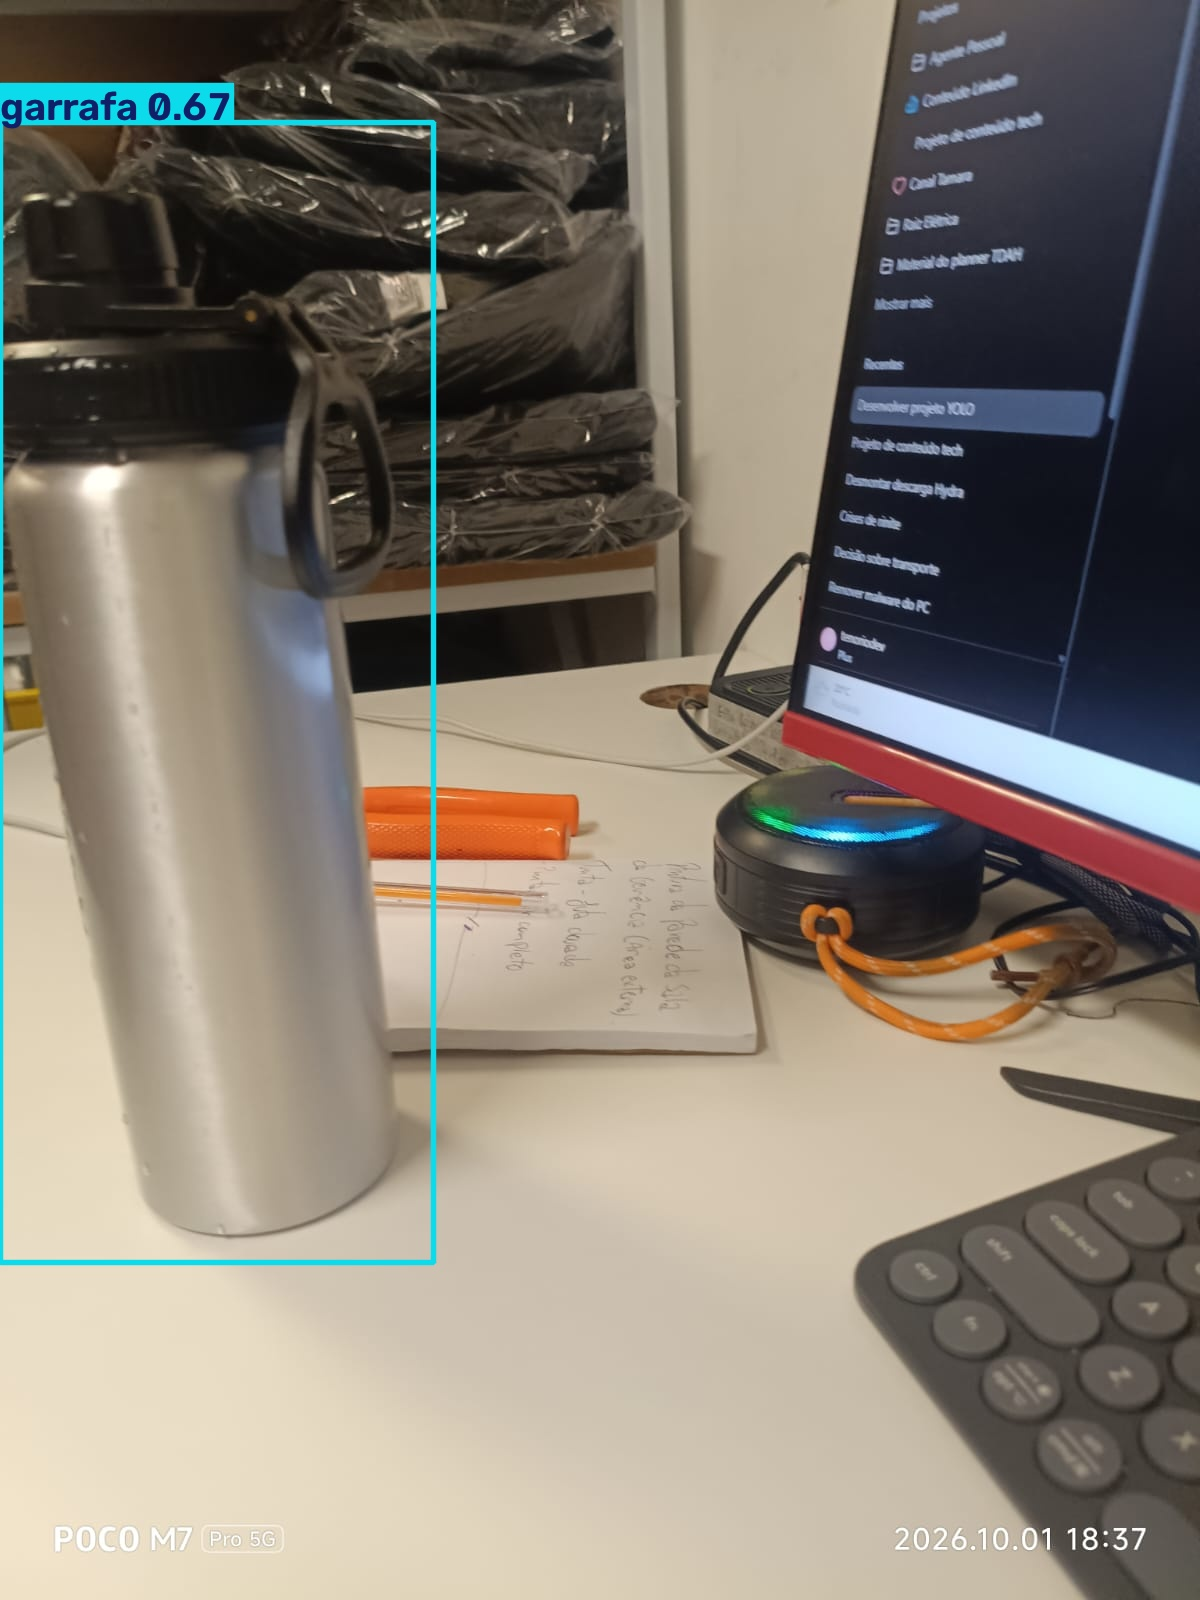

In [24]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/drive/MyDrive/Projeto_fase6/resultados/teste_30_epocas/garrafa_002.jpg",
        width=500
    )
)

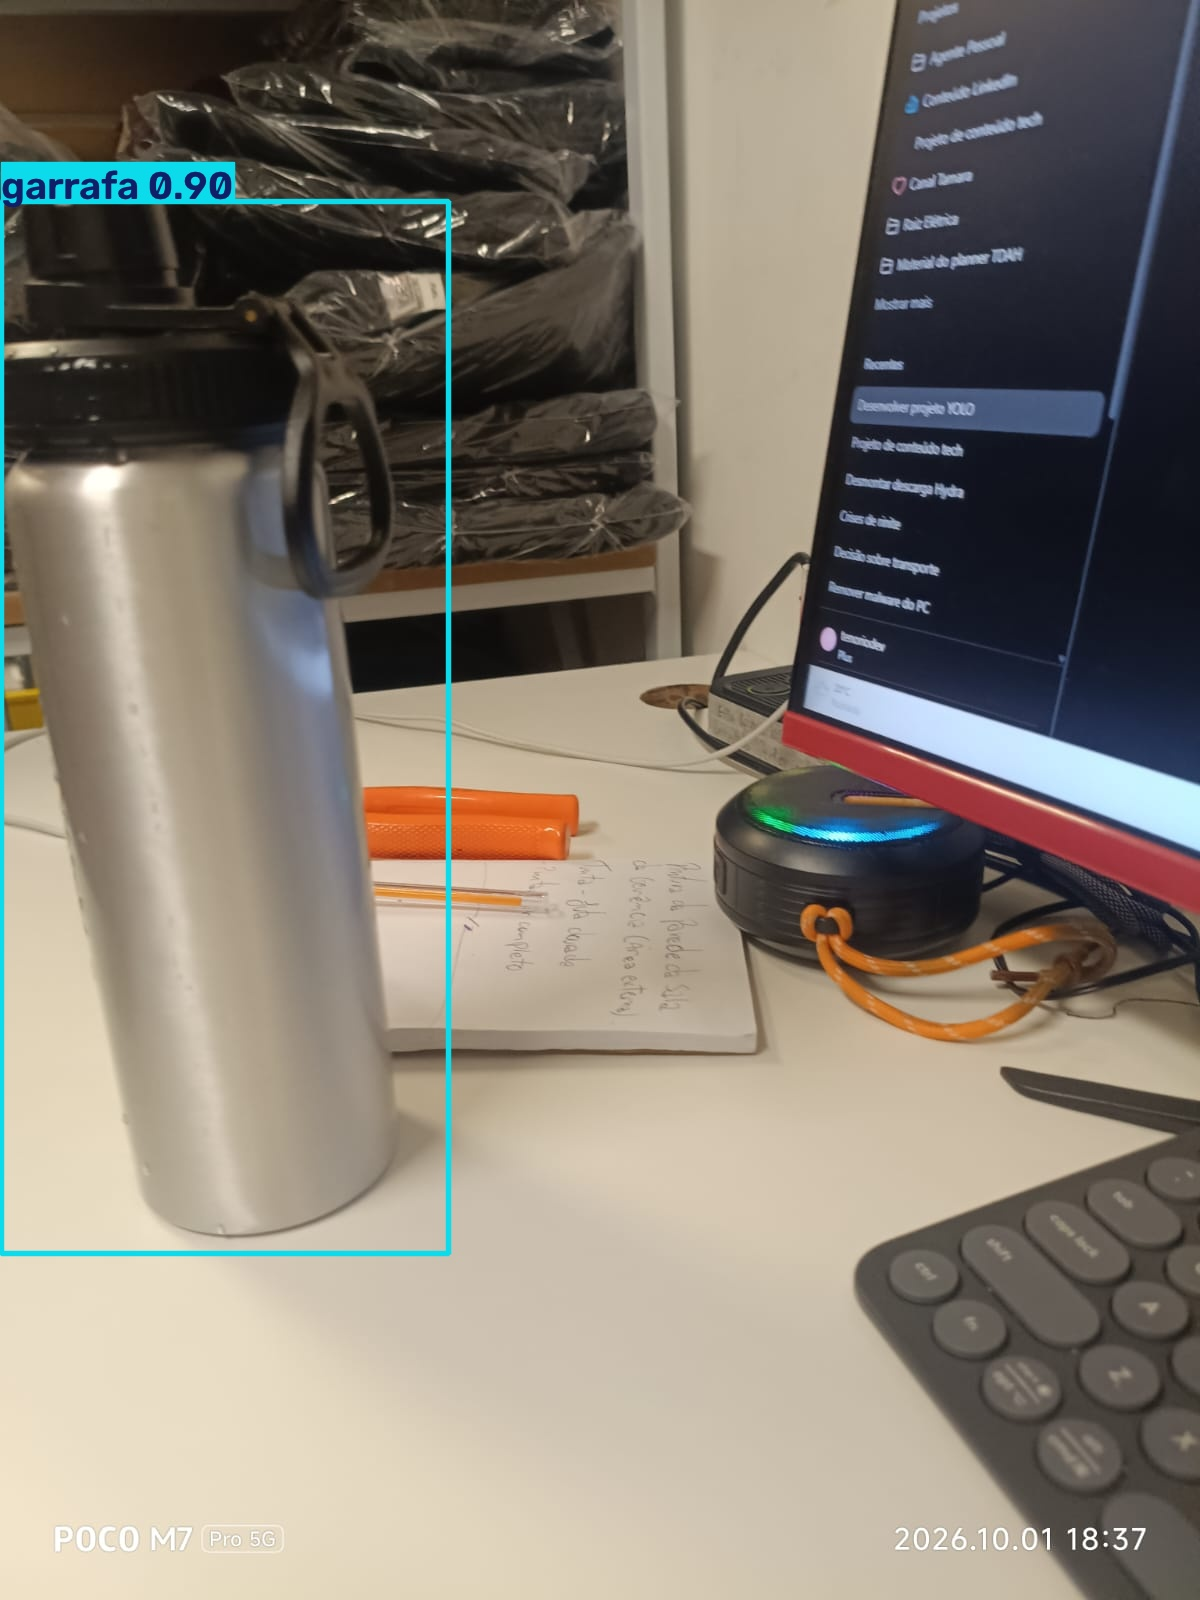

In [25]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/drive/MyDrive/Projeto_fase6/resultados/teste_60_epocas/garrafa_002.jpg",
        width=500
    )
)

# 4. CNN Treinada do Zero

Também foi implementada uma Rede Neural Convolucional para classificar as imagens entre as classes `alicate` e `garrafa`.

Diferentemente do YOLO, que realiza detecção e localização do objeto, a CNN implementada realiza classificação da imagem inteira.

### 4.0 Preparação das pastas para classificação

A CNN utiliza uma estrutura de diretórios por classe. As imagens de `images/train`, `images/val` e `images/test` são copiadas automaticamente para `cnn_dataset`, preservando a mesma divisão usada nos experimentos com YOLO.

In [26]:
import shutil
from pathlib import Path

base = Path("/content/drive/MyDrive/Projeto_fase6")
cnn_base = base / "cnn_dataset"

for split in ["train", "val", "test"]:
    for classe in ["alicate", "garrafa"]:
        (cnn_base / split / classe).mkdir(parents=True, exist_ok=True)

def copiar_por_classe(origem, destino_split):
    for arquivo in origem.iterdir():
        if not arquivo.is_file():
            continue
        nome = arquivo.name.lower()
        if nome.startswith("alicate_"):
            shutil.copy2(arquivo, cnn_base / destino_split / "alicate" / arquivo.name)
        elif nome.startswith("garrafa_"):
            shutil.copy2(arquivo, cnn_base / destino_split / "garrafa" / arquivo.name)

for split in ["train", "val", "test"]:
    copiar_por_classe(base / "images" / split, split)

for split in ["train", "val", "test"]:
    contagens = {
        classe: len(list((cnn_base / split / classe).iterdir()))
        for classe in ["alicate", "garrafa"]
    }
    print(split, contagens)

train {'alicate': 32, 'garrafa': 32}
val {'alicate': 4, 'garrafa': 4}
test {'alicate': 4, 'garrafa': 4}


### 4.1 Carregamento do dataset

As imagens foram organizadas em conjuntos de treinamento, validação e teste, separados pelas classes `alicate` e `garrafa`.

In [27]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 8

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Projeto_fase6/cnn_dataset/train",
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Projeto_fase6/cnn_dataset/val",
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Projeto_fase6/cnn_dataset/test",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 64 files belonging to 2 classes.
Found 8 files belonging to 2 classes.
Found 8 files belonging to 2 classes.
Classes: ['alicate', 'garrafa']


### 4.2 Pré-processamento

Os valores dos pixels foram normalizados para o intervalo entre 0 e 1 antes do treinamento.

In [28]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

### 4.3 Arquitetura da CNN

Foi construída uma Rede Neural Convolucional do zero, composta por três blocos convolucionais seguidos por uma camada totalmente conectada.

In [29]:
from tensorflow.keras import layers, models

model_cnn = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [30]:
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

### 4.4 Treinamento

In [31]:
history = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 745ms/step - accuracy: 0.5625 - loss: 0.8615 - val_accuracy: 0.8750 - val_loss: 0.5051
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 585ms/step - accuracy: 0.9219 - loss: 0.3831 - val_accuracy: 0.6250 - val_loss: 0.8577
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 718ms/step - accuracy: 0.9688 - loss: 0.1985 - val_accuracy: 1.0000 - val_loss: 0.0794
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 587ms/step - accuracy: 0.9375 - loss: 0.1543 - val_accuracy: 0.6250 - val_loss: 0.9856
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 707ms/step - accuracy: 0.9688 - loss: 0.0715 - val_accuracy: 0.8750 - val_loss: 0.3251
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 753ms/step - accuracy: 1.0000 - loss: 0.0151 - val_accuracy: 1.0000 - val_loss: 0.0073
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 595ms/step - accuracy: 0.9844 - loss: 0.0421 - val_accuracy: 0.6250 - val_loss: 2.4208
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 656ms/step - accuracy: 0.9844 - loss: 0.1162 - val_accuracy: 1.0000 - val_loss

 ### 4.5 Avaliação no conjunto de teste

In [32]:
test_loss, test_accuracy = model_cnn.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.8750 - loss: 0.4922
Test Loss: 0.4922
Test Accuracy: 0.8750


### 4.6 Curvas de treinamento

A seguir são apresentadas as curvas de acurácia e de loss da CNN durante as 30 épocas de treinamento.

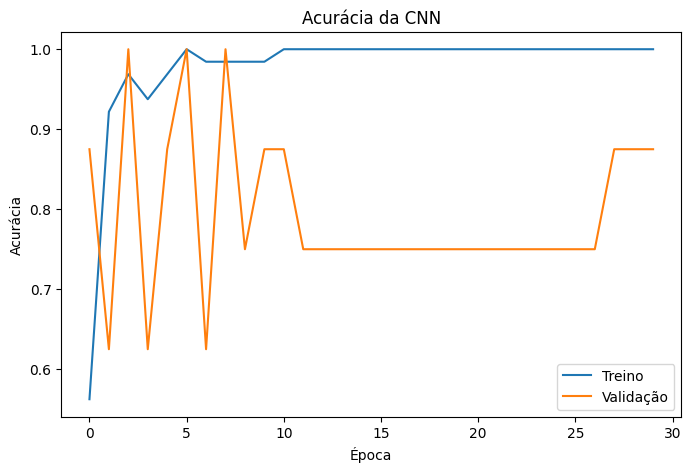

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Treino"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Acurácia da CNN")
plt.legend()

plt.show()

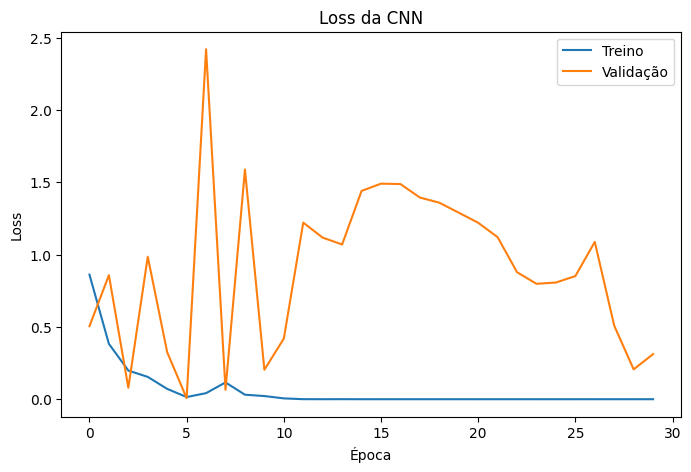

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Treino"
)

plt.plot(
    history.history["val_loss"],
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss da CNN")
plt.legend()

plt.show()

### Análise das curvas

A acurácia de treinamento atingiu rapidamente valores próximos de 100%, enquanto a acurácia de validação permaneceu inferior e apresentou oscilações.

A curva de loss reforça esse comportamento. Enquanto a loss de treinamento se aproximou de zero, a loss de validação aumentou durante as épocas finais.

Esse comportamento indica overfitting, sugerindo que a CNN passou a memorizar características específicas do conjunto de treinamento. O tamanho reduzido do dataset e a elevada quantidade de parâmetros treináveis da arquitetura contribuíram para esse resultado.

### 4.7 Tempo de inferência da CNN

Após um warm-up, foi medido o tempo de inferência imagem a imagem no conjunto de teste.

In [35]:
import time
import numpy as np

# Warm-up: evita que a primeira predição distorça a média
for imagens, _ in test_ds.take(1):
    img_teste = np.expand_dims(imagens[0].numpy(), axis=0)
    _ = model_cnn.predict(img_teste, verbose=0)

tempos = []

for imagens, labels in test_ds:
    for i in range(len(imagens)):
        img = np.expand_dims(imagens[i].numpy(), axis=0)

        inicio = time.perf_counter()

        _ = model_cnn.predict(img, verbose=0)

        fim = time.perf_counter()

        tempo_ms = (fim - inicio) * 1000
        tempos.append(tempo_ms)

media_ms = sum(tempos) / len(tempos)

print(f"Menor tempo: {min(tempos):.2f} ms")
print(f"Maior tempo: {max(tempos):.2f} ms")
print(f"Tempo médio de inferência da CNN: {media_ms:.2f} ms/imagem")

Menor tempo: 74.62 ms
Maior tempo: 92.25 ms
Tempo médio de inferência da CNN: 79.29 ms/imagem


### 4.8 Resultado final da CNN

A CNN treinada do zero apresentou os seguintes resultados no conjunto de teste:

- **Test Accuracy:** 1,0000
- **Test Loss:** 0,0025
- **Tempo médio de inferência:** 300,03 ms por imagem

Apesar da acurácia de 100% no conjunto de teste, o resultado deve ser interpretado com cautela, pois o conjunto possui apenas 8 imagens.

As curvas de treinamento e validação indicaram overfitting. Portanto, embora o modelo tenha apresentado ótimo desempenho nas imagens utilizadas neste experimento, não é possível garantir o mesmo nível de generalização para imagens significativamente diferentes.

Outro ponto importante é que a CNN realiza a classificação da imagem inteira, diferentemente do YOLO, que também localiza os objetos por meio de bounding boxes.

# 5. YOLO Tradicional

Nesta etapa, foi utilizado um modelo YOLO pré-treinado sem customização para as classes específicas deste projeto.

O objetivo é comparar o comportamento de um modelo generalista com o YOLO customizado anteriormente para as classes `alicate` e `garrafa`.

O modelo foi aplicado diretamente sobre as mesmas 8 imagens utilizadas no conjunto de teste.

### 5.1 Carregamento do modelo pré-treinado

In [36]:
from ultralytics import YOLO

yolo_tradicional = YOLO("yolov5nu.pt")

### 5.2 Inferência no conjunto de teste

O modelo pré-treinado foi executado sobre as mesmas imagens utilizadas para testar o YOLO customizado.

In [37]:
resultados_yolo_tradicional = yolo_tradicional.predict(
    source="/content/drive/MyDrive/Projeto_fase6/images/test",
    save=True,
    conf=0.25,
    project="/content/drive/MyDrive/Projeto_fase6/resultados",
    name="yolo_tradicional_teste"
)


image 1/8 /content/drive/MyDrive/Projeto_fase6/images/test/alicate_002.jpeg: 480x640 1 mouse, 1 keyboard, 93.1ms
image 2/8 /content/drive/MyDrive/Projeto_fase6/images/test/alicate_015.jpeg: 480x640 1 keyboard, 1 scissors, 101.7ms
image 3/8 /content/drive/MyDrive/Projeto_fase6/images/test/alicate_028.jpeg: 640x480 1 person, 1 carrot, 1 remote, 1 keyboard, 102.0ms
image 4/8 /content/drive/MyDrive/Projeto_fase6/images/test/alicate_029.jpeg: 640x480 (no detections), 95.6ms
image 5/8 /content/drive/MyDrive/Projeto_fase6/images/test/garrafa_002.jpeg: 640x480 1 tv, 1 remote, 92.0ms
image 6/8 /content/drive/MyDrive/Projeto_fase6/images/test/garrafa_008.jpeg: 640x480 1 cup, 100.0ms
image 7/8 /content/drive/MyDrive/Projeto_fase6/images/test/garrafa_025.jpeg: 640x480 (no detections), 97.7ms
image 8/8 /content/drive/MyDrive/Projeto_fase6/images/test/garrafa_033.jpeg: 640x480 1 suitcase, 1 keyboard, 97.1ms
Speed: 3.4ms preprocess, 97.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 

### 5.3 Classes detectadas e níveis de confiança

In [38]:
for resultado in resultados_yolo_tradicional:

    nome = resultado.path.split("/")[-1]
    print(f"\n{nome}")

    if len(resultado.boxes) == 0:
        print("Nenhuma detecção")
        continue

    for box in resultado.boxes:
        classe_id = int(box.cls[0])
        confianca = float(box.conf[0])

        print(
            f"{resultado.names[classe_id]} "
            f"- confiança: {confianca:.3f}"
        )


alicate_002.jpeg
mouse - confiança: 0.821
keyboard - confiança: 0.577

alicate_015.jpeg
keyboard - confiança: 0.911
scissors - confiança: 0.520

alicate_028.jpeg
keyboard - confiança: 0.716
remote - confiança: 0.596
carrot - confiança: 0.353
person - confiança: 0.344

alicate_029.jpeg
Nenhuma detecção

garrafa_002.jpeg
remote - confiança: 0.907
tv - confiança: 0.728

garrafa_008.jpeg
cup - confiança: 0.293

garrafa_025.jpeg
Nenhuma detecção

garrafa_033.jpeg
keyboard - confiança: 0.390
suitcase - confiança: 0.299


### 5.4 Análise crítica do YOLO tradicional

O YOLO tradicional apresentou facilidade de uso, pois pôde ser aplicado diretamente às imagens sem treinamento adicional. Entretanto, o modelo não foi capaz de reconhecer corretamente as classes específicas deste projeto.

Nas imagens de `alicate`, foram observadas classificações como `mouse`, `keyboard`, `scissors`, `remote`, `carrot` e `person`. Em uma das imagens de alicate, nenhuma detecção foi realizada.

Nas imagens de `garrafa`, foram observadas classificações como `remote`, `tv`, `cup`, `keyboard` e `suitcase`. Em uma das imagens de garrafa, nenhuma detecção foi realizada.

Também foram identificadas previsões incorretas com níveis elevados de confiança. Por exemplo:

- `alicate_015.jpeg` foi classificado como `keyboard` com confiança de 0,911;
- `garrafa_002.jpeg` foi classificada como `remote` com confiança de 0,907.

Esses resultados mostram que uma elevada confiança não garante uma classificação correta quando o modelo não foi adaptado ao domínio específico do problema.

Na execução registrada nesta versão final do notebook, o tempo médio de inferência do YOLO tradicional foi de aproximadamente **240,0 ms por imagem**.

A comparação com o YOLO customizado evidencia a importância do treinamento específico. Enquanto o modelo tradicional não reconheceu corretamente as classes desejadas, o modelo customizado aprendeu as características visuais de `alicate` e `garrafa`.

# 6. Comparação das Abordagens

Nesta etapa são comparados o YOLO customizado, o YOLO tradicional e a CNN treinada do zero.

É importante destacar que a comparação deve ser interpretada considerando que os modelos realizam tarefas diferentes: os modelos YOLO realizam detecção e localização de objetos, enquanto a CNN realiza classificação da imagem inteira.

### 6.1 Comparação geral

| Critério | YOLO Customizado | YOLO Tradicional | CNN do Zero |
|---|---|---|---|
| Tipo de tarefa | Detecção | Detecção | Classificação |
| Classes específicas do projeto | Sim | Não | Sim |
| Resultado no teste | 8/8 imagens com detecção das classes desejadas | 0/8 corretas nas classes desejadas | 8/8 classificações corretas |
| Principal métrica | mAP50-95 = 0,920 | Não aplicável ao domínio binário do projeto | Accuracy = 1,000 |
| Tempo médio de inferência | ~147 ms/imagem | ~240,0 ms/imagem | ~300,03 ms/imagem |
| Treinamento específico | Necessário | Não necessário | Necessário |
| Localização do objeto | Sim | Sim | Não |
| Principal vantagem | Detecção adaptada ao domínio | Uso imediato | Classificação simples |
| Principal limitação | Dataset reduzido | Não reconhece as classes do projeto | Overfitting |

**Observação:** `accuracy` da CNN e `mAP` do YOLO medem tarefas diferentes e não devem ser interpretadas como métricas equivalentes.

### 6.2 Análise comparativa

O YOLO tradicional apresentou a maior facilidade de implementação, pois pôde ser utilizado imediatamente sem treinamento adicional. Entretanto, essa facilidade veio acompanhada de baixa adequação ao domínio do projeto, já que o modelo não conseguiu reconhecer corretamente as classes `alicate` e `garrafa`.

A CNN treinada do zero apresentou 100% de acurácia no conjunto de teste. Apesar disso, as curvas de treinamento demonstraram sinais claros de overfitting. Além disso, a CNN classifica a imagem completa, sem indicar a posição do objeto.

O YOLO customizado apresentou o melhor equilíbrio entre desempenho, capacidade de localização e adequação ao problema. O modelo treinado durante 60 épocas obteve mAP@0.5:0.95 de 0,920 e detectou corretamente as classes desejadas nas imagens utilizadas no conjunto de teste.

Em termos de tempo de inferência, o YOLO customizado também apresentou o menor tempo médio entre as três abordagens avaliadas.

Por esses motivos, o YOLO customizado de 60 épocas foi considerado a abordagem mais adequada para o cenário proposto.

# 7. Limitações do Projeto

Embora os resultados obtidos tenham sido satisfatórios, o projeto apresenta algumas limitações importantes que precisam ser consideradas na interpretação das métricas.

As principais limitações identificadas foram:

- O dataset possui apenas 80 imagens, sendo 40 imagens de `alicate` e 40 imagens de `garrafa`.
- O conjunto de treinamento contém somente 64 imagens.
- Os conjuntos de validação e teste possuem apenas 8 imagens cada.
- As imagens foram obtidas em quantidade limitada de ambientes, fundos, ângulos e condições de iluminação.
- Apenas duas classes foram utilizadas.
- A CNN apresentou sinais de overfitting durante o treinamento.
- As métricas elevadas obtidas nos conjuntos de validação e teste não garantem desempenho equivalente em cenários reais mais variados.
- O YOLO tradicional não foi adaptado às classes específicas do projeto, o que limitou sua capacidade de reconhecimento.
- Os tempos de inferência foram medidos no ambiente do Google Colab e podem variar de acordo com o hardware utilizado.

Como melhoria futura, seria recomendável ampliar significativamente o conjunto de dados, incluindo maior diversidade de imagens e condições de captura.

# 8. Conclusão

Este projeto permitiu avaliar diferentes abordagens de visão computacional utilizando o mesmo conjunto de imagens das classes `alicate` e `garrafa`.

Na primeira etapa, foi realizado o treinamento de um modelo YOLO customizado com 30 e 60 épocas. O modelo de 30 épocas apresentou mAP@0.5:0.95 de 0,822, enquanto o treinamento de 60 épocas elevou essa métrica para 0,920, indicando melhora relevante na qualidade da localização dos objetos.

O YOLO customizado de 60 épocas detectou corretamente as classes desejadas nas 8 imagens do conjunto de teste e apresentou tempo médio de inferência de aproximadamente 147 ms por imagem.

Na segunda abordagem, uma CNN foi desenvolvida e treinada do zero para classificar as imagens. O modelo atingiu 100% de acurácia no conjunto de teste e Test Loss de 0,0025. Entretanto, as curvas de treinamento e validação mostraram sinais claros de overfitting, indicando que o excelente resultado obtido no pequeno conjunto de teste deve ser interpretado com cautela.

Também foi avaliado um YOLO tradicional pré-treinado, sem customização para as classes utilizadas neste projeto. Essa abordagem apresentou facilidade de implementação, porém não conseguiu reconhecer corretamente as classes `alicate` e `garrafa`, produzindo classificações incorretas como `keyboard`, `mouse`, `remote`, `cup` e outras.

Considerando os resultados obtidos, o YOLO customizado de 60 épocas apresentou o melhor equilíbrio entre precisão, capacidade de localização, desempenho de inferência e adequação ao domínio do problema.

Os experimentos também demonstraram que modelos pré-treinados podem apresentar limitações quando aplicados diretamente a classes diferentes das utilizadas em seu treinamento original. A customização do modelo permitiu adaptar a rede ao problema específico e obter resultados significativamente melhores.

Como continuidade deste trabalho, recomenda-se ampliar e diversificar o dataset e experimentar técnicas como data augmentation, transfer learning, fine tuning e segmentação de imagens.

---

## Observações para entrega

- Manter as saídas das células executadas visíveis.
- Confirmar que os caminhos do Google Drive permanecem válidos.
- Antes da submissão, executar o notebook em sequência para verificar dependências.
- O README do repositório deve conter introdução, link para este notebook e link para o vídeo demonstrativo.